**Titanic Exploratory Data Analysis (EDA)**

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
df = sns.load_dataset('titanic')

# Basic Exploration
print(df.info())
print(df.describe())

# Handling Missing Values
# Filling Age with median and Embarked with mode
df['age'] = df['age'].fillna(df['age'].median())
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB
None
         survived      pclass         age       sibsp       parch        f

**Q1. Passengers by Gender**

/tmp/ipykernel_11543/640688601.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='sex', palette='viridis')


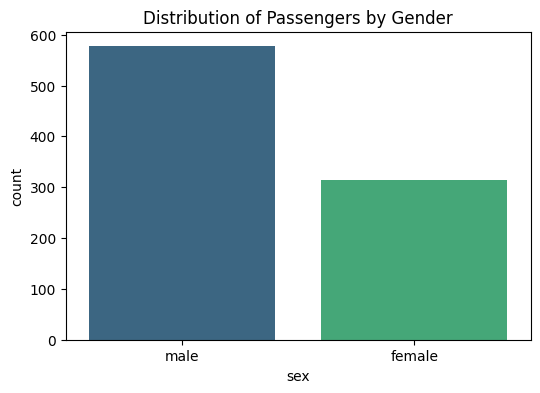

In [2]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='sex', palette='viridis')
plt.title('Distribution of Passengers by Gender')
plt.show()

**Q2. Passengers by Class**

/tmp/ipykernel_11543/2418399623.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='class', palette='Set2')


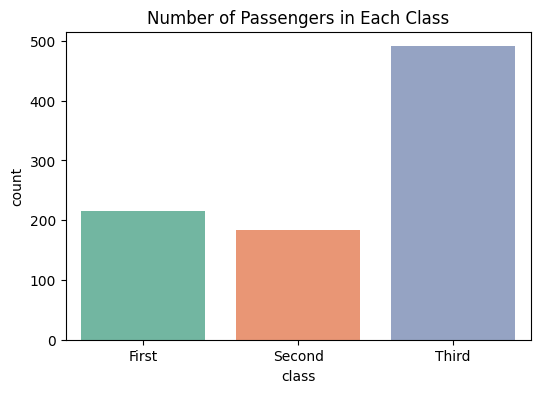

In [3]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='class', palette='Set2')
plt.title('Number of Passengers in Each Class')
plt.show()

**Q3. Age Distribution**

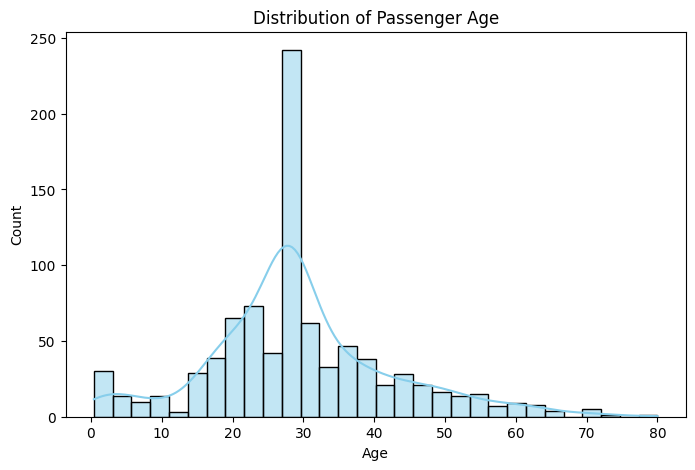

In [4]:
plt.figure(figsize=(8, 5))
sns.histplot(df['age'], bins=30, kde=True, color='skyblue')
plt.title('Distribution of Passenger Age')
plt.xlabel('Age')
plt.show()

**Q4. Fare Outliers**

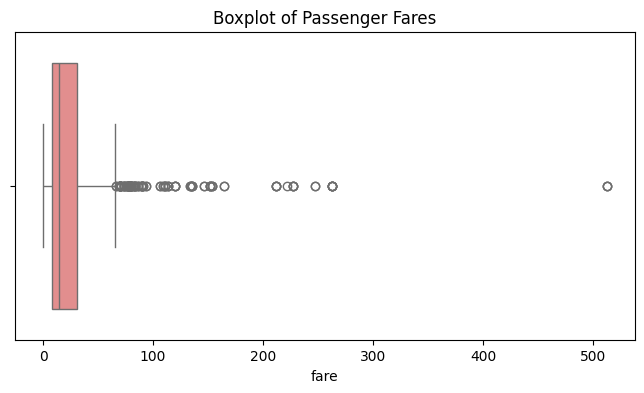

In [5]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['fare'], color='lightcoral')
plt.title('Boxplot of Passenger Fares')
plt.show()

**Q5. Scatterplots (Relationships)**

In [ ]:
# a. Age vs Fare
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='age', y='fare', alpha=0.5)
plt.title('Relationship between Age and Fare')
plt.show()

# b. Family Size vs Fare
df['family_size'] = df['sibsp'] + df['parch']
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='family_size', y='fare', alpha=0.5)
plt.title('Relationship between Family Size and Fare')
plt.show()

**Q6. Survival Count by Gender**

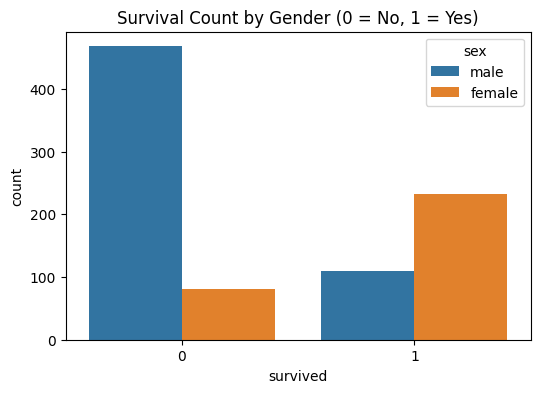

In [6]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='survived', hue='sex')
plt.title('Survival Count by Gender (0 = No, 1 = Yes)')
plt.show()

**Q7. Survival by Passenger Class**

/tmp/ipykernel_11543/2558889113.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='class', y='survived', palette='magma')


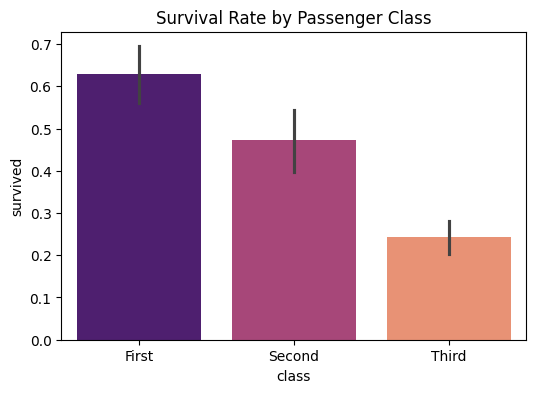

In [7]:
plt.figure(figsize=(6, 4))
sns.barplot(data=df, x='class', y='survived', palette='magma')
plt.title('Survival Rate by Passenger Class')
plt.show()

**Q8. Correlation Heatmap**

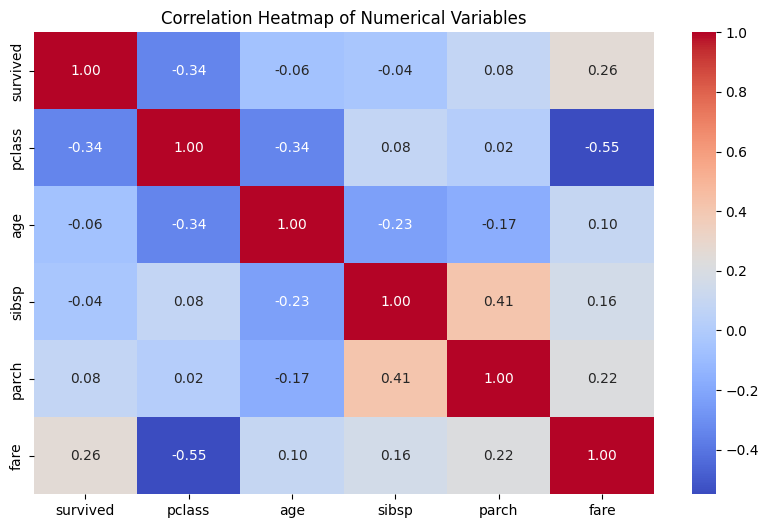

In [8]:
plt.figure(figsize=(10, 6))
# Selecting only numerical columns for correlation
corr = df.select_dtypes(include=['number']).corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Numerical Variables')
plt.show()

**Q9. Highest Average Fare Analysis**

In [9]:
avg_fare = df.groupby('class')['fare'].mean()
print(avg_fare)

class
First     84.154687
Second    20.662183
Third     13.675550
Name: fare, dtype: float64


/tmp/ipykernel_11543/2954592299.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_fare = df.groupby('class')['fare'].mean()


**Q10. Final Insights**

 -> Gender Bias in Survival: Being female was the strongest predictor of survival.

Socio-Economic Status: First-class passengers were prioritized during rescue, leading to a significantly higher survival rate compared to the third class.

Demographics: The ship was primarily populated by young adults (20-35 age range).

Fare Distribution: Ticket prices were highly skewed; most passengers paid very little, while a handful of elite passengers paid extreme premiums.

Family Influence: Passengers traveling in small families had better survival prospects than those traveling alone or in very large groups (based on family size trends).